In [5]:
import torch
import numpy as np
import tonic
import matplotlib.pyplot as plt
import tonic.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import snntorch as snn
import torch.nn as nn
import snntorch.functional as SF
from math import prod
from snntorch import spikegen, surrogate, utils
from torchvision import datasets, transforms
import statistics
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
torch.manual_seed(0);

cuda


In [6]:
transform = transforms.Compose([
            transforms.Resize((32,32)),
            transforms.ToTensor(),
            transforms.Normalize((0,), (1,))])

train_dataset = datasets.CIFAR10("./data", train=True, download=True, transform=transform)

Files already downloaded and verified


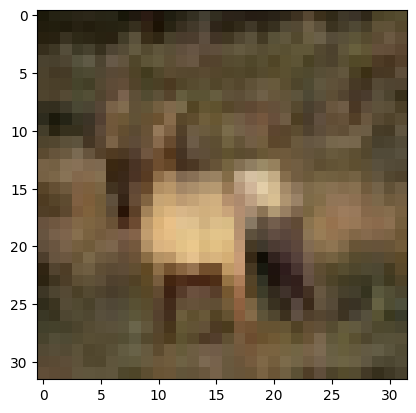

In [7]:
# plot rgb image
img, label = train_dataset[3]
plt.imshow(img.permute(1, 2, 0))
plt.show()

In [8]:
class VGG11(nn.Module):
    def __init__(self, in_channels, num_classes, spike_grad, beta=0.9, threshold=0.3, bias=False):
        super(VGG11, self).__init__()
        # [64, "M", 128, "M", 256, 256, "M", 512, 512, "M", 512, 512, "M"]
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1, bias=bias),
            snn.Leaky(beta=beta, threshold=threshold, spike_grad=spike_grad, init_hidden=True,),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=bias),
            snn.Leaky(beta=beta, threshold=threshold, spike_grad=spike_grad, init_hidden=True),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=bias),
            snn.Leaky(beta=beta, threshold=threshold, spike_grad=spike_grad, init_hidden=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=bias),
            snn.Leaky(beta=beta, threshold=threshold, spike_grad=spike_grad, init_hidden=True),
            nn.AvgPool2d(kernel_size=2, stride=2),
            #nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=bias),
            #snn.Leaky(beta=beta, threshold=threshold, spike_grad=spike_grad, init_hidden=True),
            #nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=bias),
            #snn.Leaky(beta=beta, threshold=threshold, spike_grad=spike_grad, init_hidden=True),
            #nn.AvgPool2d(kernel_size=2, stride=2),
            #nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=bias),
            #snn.Leaky(beta=beta, threshold=threshold, spike_grad=spike_grad, init_hidden=True),
            #nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=bias),
            #snn.Leaky(beta=beta, threshold=threshold, spike_grad=spike_grad, init_hidden=True),
            #nn.AvgPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 4 * 4, 1024, bias=bias),
            snn.Leaky(beta=beta, threshold=threshold, spike_grad=spike_grad, init_hidden=True),
            nn.Linear(1024, 1024, bias=bias),
            snn.Leaky(beta=beta, threshold=threshold, spike_grad=spike_grad, init_hidden=True),
            nn.Linear(1024, num_classes, bias=bias),
            snn.Leaky(beta=beta, threshold=1e9, spike_grad=spike_grad, init_hidden=True, output=True),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x
    
    def reset_state(self):
        for layer in self.features:
            if isinstance(layer, snn.Leaky):
                layer.reset_hidden()
                layer.detach_hidden()
        for layer in self.classifier:
            if isinstance(layer, snn.Leaky):
                layer.reset_hidden()
                layer.detach_hidden()
    
spike_grad = surrogate.atan()

## Start training
For training, we use the standard PyTorch training loop with some snnTorch specific functions. Instead of calling a forward pass on the network, we call the forward function of the simulator. This function takes the input data and the time step, and returns the output spikes of the network. The output spikes can then be used to calculate the loss and update the weights of the network.

In [5]:
model = VGG11(3, 10, spike_grad=spike_grad).to(device)
#async_simulator.load_state_dict(torch.load('./cifar10_asynctorch.pt'))
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True)
model.train()
n_epochs = 10
#timesteps = 10
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)#, weight_decay=1e-5)
#loss_fn = SF.ce_rate_loss() #
loss_fn = nn.CrossEntropyLoss()
accuracy_function = SF.accuracy_rate
losses = []
accuracies = []
for epoch in range(n_epochs):
    batch_iter = iter(train_dataloader)
    for data, targets in tqdm(batch_iter):
        data = data.to(device)
        #data = spikegen.rate(data, timesteps) #
        targets = targets.to(device)
        model.reset_state()

        # Forward pass
        #ys = [] #
        #for t in range(data.shape[0]): #
        #    ts_data = data[t] #
        #    spk_out, _ = model(ts_data) #
        #    ys.append(spk_out) #
        _,y = model(data)
        #y = torch.stack(ys) #
        loss = loss_fn(y, targets)
        losses.append(loss.item())
        predictions = torch.argmax(y, dim=1)
        accuracy = predictions.eq(targets).float().mean().cpu().item()
        #accuracy = accuracy_function(y, targets) #
        accuracies.append(accuracy)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

100%|██████████| 391/391 [00:06<00:00, 63.92it/s]


### Check training progress

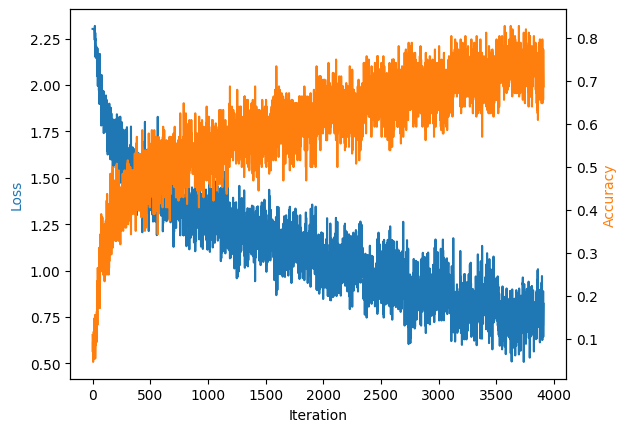

Accuracy:  0.719140625


In [6]:
fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.plot(losses, color='C0')
ax2.plot(accuracies, color='C1')

ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss', color='C0')
ax2.set_ylabel('Accuracy', color='C1')

plt.show()
print("Accuracy: ", statistics.mean(accuracies[-100:]))